# Downloading Digital Surface Model (DSM) and Digital Terrain Model (DTM) files
### Demonstration Notebooks
#### Author: Rafael Barbedo | Date: 2025-03-12

Digital Elevation data derived from LiDAR—specifically Digital Terrain Models (DTMs) and Digital Surface Models (DSMs)—are highly valuable for a wide range of geospatial analyses, including hydrology, terrain characterisation, and land assessment.

This notebook demonstrates how to **download, extract and visualise** DSM and DTM data for a user-defined region of interest (ROI).

- **DTM** (Digital Terrain Model): Represents the bare-earth surface, with vegetation and built structures removed.
- **DSM** (Digital Surface Model): Includes surface features such as vegetation, buildings, and other structures.

Subsequent notebooks will build on these datasets to perform more advanced analyses (e.g. hydrological modelling and canopy assessment). In this notebook, we focus on data acquisition and preprocessing.

A shapefile representing the study catchment is used to define the region of interest (ROI). This is used to generate a bounding box, which is then applied to clip the DTM and DSM datasets.

All processing steps are reproducible using open-source tools.

**Required inputs:**
- Shapefile or bounding box for region of interest

**Workflow overview:**
- Define inputs
- Handle CRS
- ROI extraction
- Preprocessing
- Outputs

**Outputs:**
- Interactive 3D Terrain Model
- TIFF files: DTM and DSM extracted for ROI

First, will start with importing the necessary libraries...

In [1]:
# Import the necessary pacakages
import subprocess
import sys
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import rasterio
import plotly.graph_objects as go
from matplotlib import colormaps
from rasterio.enums import Resampling

In [2]:
# Define input files as global variables:
input_dtm_raster = "/vsicurl/https://fdri-o.s3-ext.jc.rl.ac.uk/lidar/joined/merged_engwal_dtm.tif"
input_dsm_raster = "/vsicurl/https://fdri-o.s3-ext.jc.rl.ac.uk/lidar/joined/merged_engwal_dsm.tif"

input_shp = "/home/users/ambbar/GIthub/data/nrfa_39088/NRFA_catchments.shp"
output_dtm_raster = "/home/users/ambbar/GIthub/data/output/dtm_39088_extract.tif"
output_dsm_raster = "/home/users/ambbar/GIthub/data/output/dsm_39088_extract.tif"

In [3]:
def correct_crs(input_dtm: str, input_shapefile: str, shapefile_crs: str | None = None,)-> gpd.GeoDataFrame:

    """
    Ensure that the CRS of the input shapefile matches the DTM/DSM rasters.

    If the shapefile has no CRS, it is assigned using `shapefile_crs`.
    If the CRS differs, the shapefile is reprojected to match the raster CRS.

    Also prints resolution and spatial extent for validation.

    Parameters
    ----------
    input_dtm : Path or str
        Path to the DTM raster
    input_dsm : Path or str <<
        Path to the DSM raster
    input_shapefile : Path or str
        Path to the shapefile
    shapefile_crs : str, optional
        CRS to assign if shapefile has none (e.g. "EPSG:27700")

    Returns
    -------
    gpd.GeoDataFrame
        Shapefile reprojected to match raster CRS
    """

    # Load the data with geopandas
    roi_gdf = gpd.read_file(input_shapefile)

    # store the crs, resolution and bounds of the DTM
    with rasterio.open(input_dtm) as dtm:
        dtm_crs = dtm.crs
        # dtm_res = dtm.res
        # dtm_bounds = dtm.bounds

    # Check there is a defined coordinate reference system
    if roi_gdf.crs is None:
        if shapefile_crs.crs is None:
            raise ValueError("Shapefile CRS is undefined. Please provide `shapefile_crs`.")

        roi_gdf = roi_gdf.set_crs(shapefile_crs)

    # Reproject if needed
    if roi_gdf.crs != dtm_crs:
        print(f"Reprojecting shapefile from {roi_gdf.crs} to {dtm_crs}")
        roi_gdf = roi_gdf.to_crs(dtm_crs)
    else:
        print(f"DTM CRS of {dtm.crs} already matches the shapefile CRS of {roi_gdf.crs}")

    return roi_gdf

In [4]:
roi_gdf = correct_crs(input_dtm_raster, input_shp)
print(roi_gdf)

roi_gdf_path = "/home/users/ambbar/GIthub/data/output/roi.shp"
roi_gdf.to_file(roi_gdf_path)


DTM CRS of EPSG:27700 already matches the shapefile CRS of EPSG:27700
        ID ID_STRING     ceast    cnorth       area  \
0  39088.0     39088  496058.0  202802.0  96.911563   

                                            geometry  
0  POLYGON ((506575 194775, 506525 194775, 506525...  


### Now, using gdal_translate to get hold of the DTM data at the area of study, resampled to 5 m. We also converted the data to metres, and float.

Using the DTM for England and Wales, select a shapefile of your study area to clip the raster to and define an output for this new clipped raster. The pixel size is the size of the individual grid cells that make up the raster image, a lower value will give a higher resolution. In this case, 5 represents grid cells of 5m and an optional buffer of 1000m. Processing will be much faster when selecting a smaller bounding box.

In [5]:
# The function get_raster_at_roi is used to extract dtm and dsm data for a region of interest.
def get_raster_at_roi(input_raster, input_shp, output_raster, pixel_size=5, buffer=1000):
    """
    Extracts a raster for a region of interest (ROI) defined by a shapefile.
    The function retrieves a raster from an online source (e.g., AWS S3, URL), 
    clips it to the shapefile extent with an optional buffer, and saves it locally.

    Parameters:
    - input_raster (str): URL or S3 path to the input raster.
    - input_shp (str): Path to the shapefile defining the region of interest (ROI).
    - output_raster (str): Path to save the clipped raster.
    - pixel_size (int, optional): Output pixel size in meters (default = 5m).
    - buffer (int, optional): Buffer distance (meters) to extend the clipping extent (default = 1000m).

    Returns:
    - Prints GDAL command output **in real-time** and saves the clipped raster.
    """
    # Extract extent from shapefile
    ogrinfo_cmd = f"ogrinfo -al -so {input_shp} | grep 'Extent' | sed 's/Extent: //; s/[(,)]//g'"
    extent_output = subprocess.run(ogrinfo_cmd, shell=True, capture_output=True, text=True)

    if extent_output.returncode != 0:
        print(f"❌ Error retrieving shapefile extent: {extent_output.stderr}")
        return

    # Read extracted extent
    extent = extent_output.stdout.strip()
    if not extent:
        print("❌ No extent data retrieved. Check if the shapefile exists and is valid.")
        return

    print(f"✅ Extracted extent: {extent}")

    try:
        min_x, min_y, _, max_x, max_y = extent.split()
        min_x, min_y, max_x, max_y = map(float, [min_x, min_y, max_x, max_y])
    except ValueError:
        print("❌ Error parsing extent coordinates.")
        return

    # Compute buffered extent
    new_min_x = min_x - buffer
    new_min_y = min_y - buffer
    new_max_x = max_x + buffer
    new_max_y = max_y + buffer

    print(f"📏 Buffered Extent: ({new_min_x}, {new_min_y}, {new_max_x}, {new_max_y})")

    # GDAL Translate command to clip the raster
    gdal_cmd = f"""
    gdal_translate -projwin {new_min_x} {new_max_y} {new_max_x} {new_min_y} \
        -tr {pixel_size} {pixel_size} -ot Float32 -scale 0 1000 0 1 \
        -of GTiff {input_raster} {output_raster}
    """

    print("🚀 Running GDAL Translate...")
    print(f"🖥️ GDAL Command:\n{gdal_cmd}")

    # Run GDAL command and stream output in real-time
    process = subprocess.Popen(
        gdal_cmd,
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,  # Line buffering
        universal_newlines=True  # Ensures proper streaming of text
    )

    # Stream real-time output **without buffering**
    for line in iter(process.stdout.readline, ""):
        sys.stdout.write(line)
        sys.stdout.flush()  # Ensure immediate output

    process.wait()  # Ensure process completes

    if process.returncode == 0:
        print(f"\n✅ Clipped raster successfully saved as: {output_raster}")
    else:
        print(f"\n❌ Error during clipping. Exit code: {process.returncode}")

In [6]:
# Run the function
get_raster_at_roi(input_dtm_raster, roi_gdf_path, output_dtm_raster)

✅ Extracted extent: 488725.000000 194775.000000 - 506975.000000 210175.000000
📏 Buffered Extent: (487725.0, 193775.0, 507975.0, 211175.0)
🚀 Running GDAL Translate...
🖥️ GDAL Command:

    gdal_translate -projwin 487725.0 211175.0 507975.0 193775.0         -tr 5 5 -ot Float32 -scale 0 1000 0 1         -of GTiff /vsicurl/https://fdri-o.s3-ext.jc.rl.ac.uk/lidar/joined/merged_engwal_dtm.tif /home/users/ambbar/GIthub/data/output/dtm_39088_extract.tif
    
Input file size is 576000, 661000
0...10...20...30...40...50...60...70...80...90...100 - done.

✅ Clipped raster successfully saved as: /home/users/ambbar/GIthub/data/output/dtm_39088_extract.tif


In [7]:
# Run the function
get_raster_at_roi(input_dsm_raster, roi_gdf_path, output_dsm_raster)

✅ Extracted extent: 488725.000000 194775.000000 - 506975.000000 210175.000000
📏 Buffered Extent: (487725.0, 193775.0, 507975.0, 211175.0)
🚀 Running GDAL Translate...
🖥️ GDAL Command:

    gdal_translate -projwin 487725.0 211175.0 507975.0 193775.0         -tr 5 5 -ot Float32 -scale 0 1000 0 1         -of GTiff /vsicurl/https://fdri-o.s3-ext.jc.rl.ac.uk/lidar/joined/merged_engwal_dsm.tif /home/users/ambbar/GIthub/data/output/dsm_39088_extract.tif
    
Input file size is 523000, 646601
0...10...20...30...40...50...60...70...80...90...100 - done.

✅ Clipped raster successfully saved as: /home/users/ambbar/GIthub/data/output/dsm_39088_extract.tif


## Now let's visualize our dataset

In [8]:
# Load raster with rasterio to get georeferencing
def plot_raster_with_histogram(raster_path: str, title: str):
    """ 
    Plot a raster with real-world extent, colour scaling and histogram.

    Parameters:
    raster_path : str
        Path to raster file
    title : str
        Title for the plot
    """
    with rasterio.open(raster_path) as src:
        raster = src.read(1)  # Read the first band
        bounds = src.bounds  # Get raster bounding box
        nodata = src.nodata  # NoData value

    # Mask out NoData values
    if nodata is not None:
        valid_data = raster[raster != nodata]
    else:
        valid_data = raster[~np.isnan(raster)]

    if valid_data.size == 0:
        raise ValueError("No valid raster values found.")

    # Compute Color Normalization
    datamin = np.percentile(valid_data, 2)
    datamax = np.percentile(valid_data, 98)
    norm = colors.Normalize(vmin=datamin, vmax=datamax)
    cmap = "terrain"

    # Compute Real-World Extent
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    # Plot
    _, ax = plt.subplots(figsize=(10, 6))

    # Display the raster with real-world extent
    img = ax.imshow(raster, cmap=cmap, norm=norm, extent=extent, origin="upper")

    # Display the raster with real-world extent #img =
    ax.imshow(raster, cmap=cmap, norm=norm, extent=extent, origin="upper")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_title(title)
    
    # Create a colorbar
    cbar = plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Elevation (m)")
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = ax.inset_axes([1.3, 0.35, 0.06, 0.5])  # Position the colorbar inset
    cbar = plt.colorbar(sm, cax=cax)
    cbar.ax.tick_params(labelsize=8)
    cax.yaxis.set_ticks_position('right')
    cax.yaxis.set_label_position('right')

    # Histogram inset
    hax = ax.inset_axes([1.2, 0.05, 0.25, 0.25])
    colormap = plt.colormaps.get_cmap(cmap)

    # Filter raster values for histogram
    data = valid_data[(valid_data > datamin) & (valid_data < datamax)]

    # Plot % histogram
    n = len(data)
    _, bins, patches = hax.hist(data, bins=20, edgecolor='none', weights=np.ones(n)/n*100)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Normalize bin centers to [0, 1]
    col = (bin_centers - min(bin_centers)) / (max(bin_centers) - min(bin_centers))

    for c, p in zip(col, patches):
            plt.setp(p, 'facecolor', colormap(c))

    hax.set_xlabel('Elevation (m)')
    hax.set_ylabel('Occupation (%)')
    hax.yaxis.set_ticks_position('right')
    hax.yaxis.set_label_position('right')

    plt.tight_layout()
    plt.show()

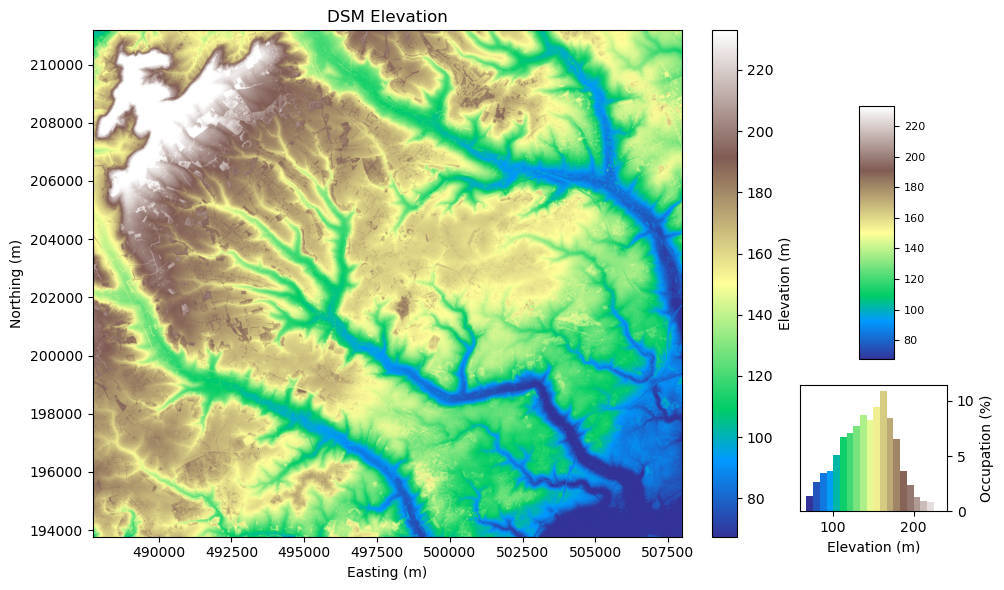

In [9]:
plot_raster_with_histogram(output_dsm_raster, "DSM Elevation")

## For interactive visualization

## 3D visualization

In [18]:
# Load the Raster
raster_path = output_dtm_raster

# Read the raster and resample for performance
with rasterio.open(raster_path) as src:

    # reducing the resolution by a factor of 10 to help with performance. 
    scale = 10

    new_height = src.height // scale
    new_width = src.width // scale

# Read the first band (elevation) with resampling
    data = src.read(
        1,
        out_shape=(new_height, new_width),
        resampling=Resampling.bilinear
    )

# Get the spatial transform
    transform = src.transform * src.transform.scale(
        src.width / new_width,
        src.height / new_height
    )

    rows, cols = data.shape

    # convert pixel indices into real world coordinates
    x_coords = np.arange(cols) * transform.a + transform.c
    y_coords = np.arange(rows) * transform.e + transform.f

    X, Y = np.meshgrid(x_coords, y_coords)


# Mask nodata values
    nodata = src.nodata
    data = np.where(data == nodata, np.nan, data)


# Plotly interactive surface
    fig = go.Figure(
        data=[
            go.Surface(
                z=data,
                x=X,
                y=Y,
                colorscale="ylgnbu_r"
            )
        ]
    )
# Layout + styling
    fig.update_layout(
        title="Interactive 3D Terrain Model",
        scene=dict(
            xaxis_title="Easting",
            yaxis_title="Northing",
            zaxis_title="Elevation (m)",
            aspectratio=dict(x=1, y=1, z=0.3)
        ),
        margin=dict(l=0, r=0, t=40, b=0)
    )
# Show plot
    fig.show()